# 미추홀구 유튜브 여론·민원 분석 파이프라인 시연
**인천대학교 × 미추홀구청 관학협력 프로젝트**

파이프라인: `crawl_YT` → `complaint_analysis` → `regression`

- 아래 **시스템 구조 다이어그램**에서 노드를 클릭하거나 마우스를 올리면 연결 경로가 보입니다.
- 단계 진행 상태는 실행에 따라 **실시간으로 갱신**됩니다.
- 별도 브라우저 대시보드(`pipeline_dashboard.html`)에도 같은 다이어그램과 각 단계 산출물(표·그림)이 함께 표시됩니다.
- 시연 모드: 크롤링·LLM 분석은 사전 수집/분석된 CSV를 사용합니다 (API 키·시간 제약 없이 재현).

In [ ]:
import time
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display
from pipeline_viz import PipelineViz, start_dashboard, show_diagram

# 별도 대시보드 서버 시작 (출력된 URL을 브라우저로 열어두세요)
start_dashboard(port=8765)

viz = PipelineViz([
    ("crawl",      "1. crawl_YT",            "YouTube API 댓글 수집"),
    ("analysis",   "2. complaint_analysis",  "LLM 감성·민원 유형 분류"),
    ("regression", "3. regression",          "가설검정·회귀분석"),
])

# 대시보드와 동일한 시스템 구조 다이어그램 (노드 클릭·경로 추적 가능)
show_diagram(height=520)

---
## Stage 1 — `crawl_YT.py` : YouTube 댓글 수집
`YT.csv`의 영상 목록을 YouTube Data API v3로 순회하며 댓글(영상당 최대 500개)을 수집하고 언어를 감지해 `youtube_results.csv`로 저장합니다.

> 시연에서는 사전 수집된 `youtube_results.csv`를 로드합니다.

In [64]:
viz.start("crawl", "YT.csv 영상 목록 로드...")
video_list = pd.read_csv("./data/YT.csv"); time.sleep(1)

viz.update("crawl", f"{len(video_list)}개 영상 댓글 수집 중...")
raw = pd.read_csv("./data/youtube_results.csv"); time.sleep(1.2)

viz.update("crawl", "언어 감지(langdetect) 및 저장...")
time.sleep(0.8)
viz.log_table("crawl", video_list, "수집 대상 영상 목록 (data/YT.csv)")
viz.log_table("crawl", raw[["title","author","comment","likes","published_at"]],
              "수집된 댓글 (data/youtube_results.csv)")
viz.done("crawl", f"댓글 {len(raw):,}건 / 영상 {raw['video_id'].nunique()}개 수집")
raw.head(3)

,platform,title,url,video_id,author,comment,language,likes,published_at,type
0,YouTube,사람으로 채워지는 미추홀!ㅣ배우 이재용×김기환의 [미추홀 동네 한 바퀴] EP.2,https://youtu.be/GyILpEk7Pwg,GyILpEk7Pwg,@꽃부리영00,토지금고 시장에서 만난 젊은 상인분들의 파이팅 넘치는 모습이 기억에 남아요! 04:...,ko,1,2025-12-25T14:23:42Z,top_comment
1,YouTube,사람으로 채워지는 미추홀!ㅣ배우 이재용×김기환의 [미추홀 동네 한 바퀴] EP.2,https://youtu.be/GyILpEk7Pwg,GyILpEk7Pwg,@우가사모,미추홀구를 잘 몰랐는데 이번 영상을 통해 한 번 직접 가보고 싶어졌어요.,ko,0,2025-12-24T07:50:36Z,top_comment
2,YouTube,사람으로 채워지는 미추홀!ㅣ배우 이재용×김기환의 [미추홀 동네 한 바퀴] EP.2,https://youtu.be/GyILpEk7Pwg,GyILpEk7Pwg,@twotwonine5615,특별하거나 화려하지 않지만 사람이 사는 냄새가 나는 영상이네요..미추홀구의 은근한 ...,ko,0,2025-12-19T14:47:37Z,top_comment


---
## Stage 2 — `complaint_analysis.py` : LLM 기반 감성·민원 분석
Gemini API로 각 댓글을 **긍정/부정 분류** → 부정 댓글은 **민원 주제·내용 유형**을 추출, 긍정 댓글은 키워드 기반 유형 분류를 수행합니다. 결과는 `michuhol_analysis_raw.csv` 등으로 저장됩니다.

> 시연에서는 사전 분석된 결과 CSV를 로드합니다 (실제 실행: `python complaint_analysis.py`).

In [65]:
viz.start("analysis", "댓글 전처리·행사 언급 필터링...")
time.sleep(1)

viz.update("analysis", "Gemini로 감성/민원 유형 분류 중...")
final_df = pd.read_csv("./results/michuhol_analysis_raw.csv"); time.sleep(1.5)

viz.update("analysis", "긍정 키워드 분류·워드클라우드 생성...")
pos = pd.read_csv("./results/michuhol_positive_comments.csv")
neg = pd.read_csv("./results/michuhol_negative_comments.csv"); time.sleep(1)

perf = pd.read_csv("./results/michuhol_performance_report.csv")
viz.log_table("analysis", perf, "성과 요약 (michuhol_performance_report.csv)")
viz.log_table("analysis", neg, "민원(부정) 댓글 분류 결과")
viz.log_table("analysis", pos, "긍정 댓글 유형 분류 결과")
viz.log_image("analysis", "figures/michuhol_wordcloud_positive.png", "긍정 워드클라우드")
viz.log_image("analysis", "figures/michuhol_wordcloud_negative.png", "부정(민원) 워드클라우드")
viz.done("analysis", f"긍정 {len(pos):,} / 부정(민원) {len(neg):,}건 분류")
pd.read_csv("./results/michuhol_performance_report.csv")

,title,총댓글수,이벤트참여수,확정민원수,긍정반응수,민원발생률(%),순수긍정률(%)
0,#오늘 #인하대를 당신의 #시선으로,2,0,0,2,0.00,100.00
1,2025 미추홀구 주민자치어울마당 | 도화1동 스포츠댄스 #주민자치센터 #미추홀구 ...,1,0,0,1,0.00,100.00
2,2025 미추홀구 주민자치어울마당 | 도화2.3동 라인댄스 #주민자치센터 #미추홀구...,1,0,0,1,0.00,100.00
3,2025 미추홀구 주민자치어울마당 | 숭의4동 다이어트댄스 #주민자치센터 #미추홀구...,2,0,0,2,0.00,100.00
4,2025 미추홀구 주민자치어울마당 | 용현2동 기타교실 #주민자치센터 #미추홀구 #...,1,0,0,1,0.00,100.00
5,2025 미추홀구 주민자치어울마당 | 주안6동 방송댄스 #댄스 #이벤트 #축제 #미...,1,0,0,1,0.00,100.00
6,2025 미추홀구 주민자치어울마당 | 주안8동 핫라핏댄스 #댄스 #이벤트 #축제 #...,1,1,0,0,0.00,0.00
7,[Teaser] 이짜나언짜나와 함께하는 미추송 챌린지 이벤트,1,0,0,1,0.00,100.00
8,"[미추홀구] 병오년 새해, 언제나 행복과 건강이 함께 하길 기원드립니다😊 | 이영훈...",8,0,1,7,12.50,87.50
9,[미추홀구] 보름달처럼 밝고 풍요로운 한가위 되세요~ ㅣ 이영훈 미추홀구청장 202...,1,0,0,1,0.00,100.00


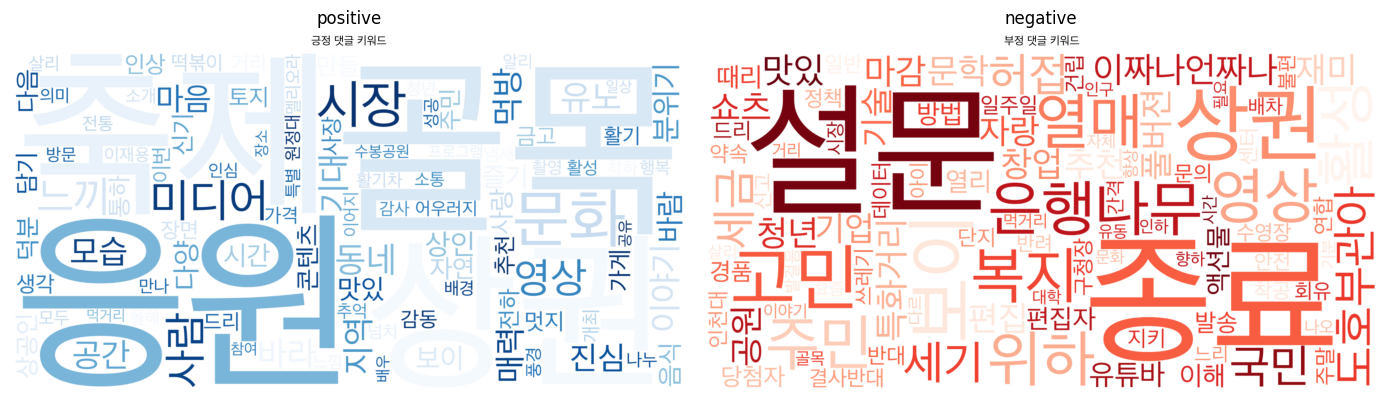

In [66]:
# 감성별 워드클라우드
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (path, title) in zip(axes, [("./figures/michuhol_wordcloud_positive.png", "positive"),
                                    ("./figures/michuhol_wordcloud_negative.png", "negative")]):
    ax.imshow(plt.imread(path)); ax.set_title(title); ax.axis("off")
plt.tight_layout(); plt.show()

---
## Stage 3 — `regression.py` : 가설검정 및 회귀분석
영상 단위로 집계한 뒤 **순열검정(permutation test)** 과 **로지스틱 회귀(오즈비)** 로
콘텐츠 유형·행사 언급 여부가 긍정률/민원율에 미치는 영향을 검정합니다.

In [67]:
viz.start("regression", "영상 단위 집계(by_title)...")
by_title = pd.read_csv("./results/hypothesis_test_by_title.csv"); time.sleep(1)

viz.update("regression", "순열검정 10,000회 수행 중...")
time.sleep(1.5)

viz.update("regression", "로지스틱 회귀 오즈비 산출...")
or_pos = pd.read_csv("./results/ref_logit_odds_positive_topic.csv")
or_neg = pd.read_csv("./results/ref_logit_odds_complaint_topic.csv"); time.sleep(1)

viz.log_table("regression", by_title, "영상 단위 집계 (hypothesis_test_by_title.csv)")
viz.log_image("regression", "figures/permutation_test_results.png", "순열검정 결과")
viz.log_image("regression", "figures/permutation_boxplot.png", "그룹별 박스플롯")
viz.log_table("regression", or_pos, "긍정률 오즈비 — 주제별")
viz.log_table("regression", or_neg, "민원율 오즈비 — 주제별")
viz.done("regression", f"영상 {len(by_title)}건 검정 완료")
by_title.head()

,title,total_comments,event_comments,complaint_comments,positive_eval_comments,cherrypick_proxy_comments,avg_comment_len,event_ratio,positive_ratio_total,non_event_comments,positive_ratio_non_event,cherrypick_proxy_ratio,complaint_ratio,is_event_video
0,#오늘 #인하대를 당신의 #시선으로,2,0,0,2,0,11.5,0.0,100.0,2,100.0,NaN,0.0,False
1,2025 미추홀구 주민자치어울마당 | 도화1동 스포츠댄스 #주민자치센터 #미추홀구 ...,1,0,0,1,0,26.0,0.0,100.0,1,100.0,NaN,0.0,False
2,2025 미추홀구 주민자치어울마당 | 도화2.3동 라인댄스 #주민자치센터 #미추홀구...,1,0,0,1,0,15.0,0.0,100.0,1,100.0,NaN,0.0,False
3,2025 미추홀구 주민자치어울마당 | 숭의4동 다이어트댄스 #주민자치센터 #미추홀구...,2,0,0,2,0,9.0,0.0,100.0,2,100.0,NaN,0.0,False
4,2025 미추홀구 주민자치어울마당 | 용현2동 기타교실 #주민자치센터 #미추홀구 #...,1,0,0,1,0,13.0,0.0,100.0,1,100.0,NaN,0.0,False


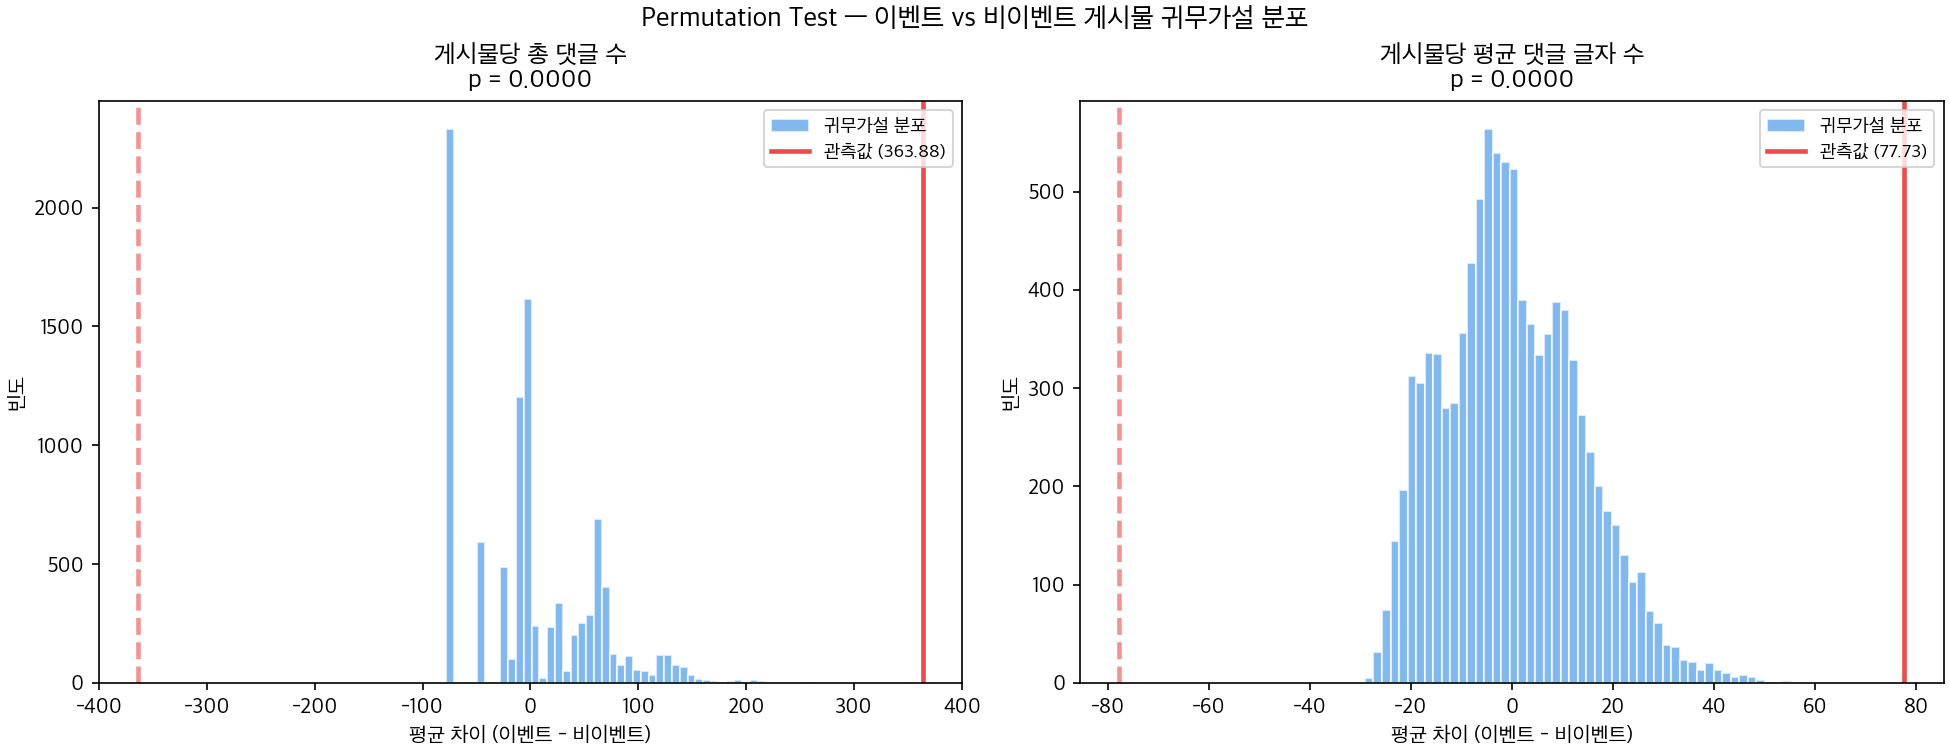

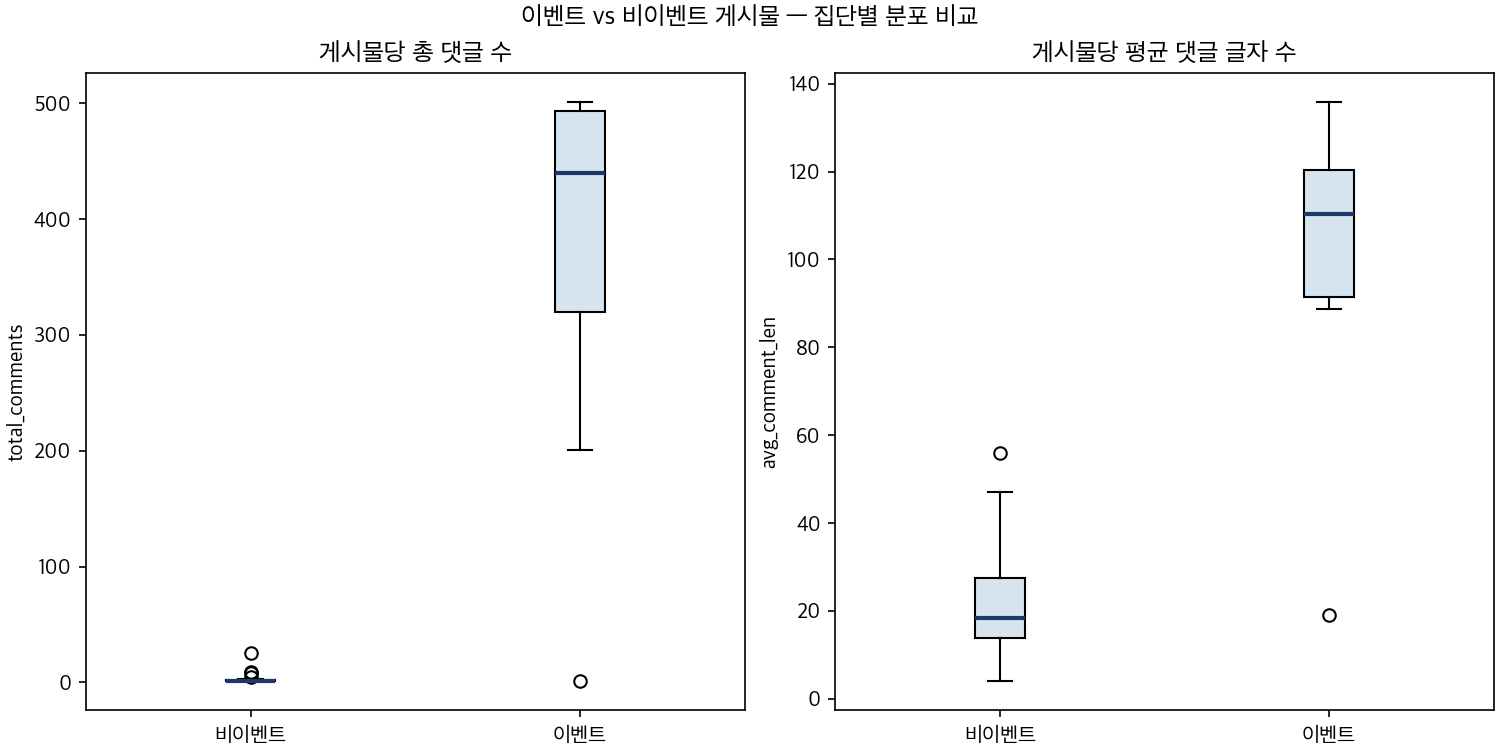

In [68]:
display(Image("./figures/permutation_test_results.png"))
display(Image("./figures/permutation_boxplot.png"))

In [69]:
print("[긍정률 오즈비 - 주제별]"); display(or_pos)
print("[민원율 오즈비 - 주제별]"); display(or_neg)

[긍정률 오즈비 - 주제별]


,outcome,category,term,coef,odds_ratio,ci_low,ci_high,p_value,ci_valid,note
0,is_positive_eval,topic,topic_문화,1.646911,5.190922,3.831669,7.032358,2.123029e-26,True,NaN
1,is_positive_eval,topic,topic_행정,0.776377,2.173584,1.819974,2.595898,1.033612e-17,True,NaN


[민원율 오즈비 - 주제별]


,outcome,category,term,coef,odds_ratio,ci_low,ci_high,p_value,ci_valid,note
0,is_complaint,topic,topic_행정,-0.153240,0.857924,NaN,NaN,NaN,False,"표본 부족 — CI 미산출, 오즈비 해석 주의"
1,is_complaint,topic,topic_문화,-9.106086,0.000111,NaN,NaN,NaN,False,"표본 부족 — CI 미산출, 오즈비 해석 주의"


---
## 파이프라인 완료
세 단계가 모두 초록색(✔)이면 수집 → 분석 → 검정의 전체 흐름이 정상 동작한 것입니다.
재시연하려면 `viz.reset()` 후 Stage 1부터 다시 실행하세요.